In [27]:
from google.colab import files

uploaded = files.upload()

Saving healthcare-dataset-stroke-data[1].csv to healthcare-dataset-stroke-data[1] (1).csv


In [28]:

import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data[1].csv")

# Display the number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

Number of Rows: 5110
Number of Columns: 12
Dataset Shape: (5110, 12)


In [29]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [30]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


ETL Pipeline


In [32]:
import pandas as pd
import os

# =====================================
# EXTRACT - Load Raw Data
# =====================================

# Create folders
os.makedirs("raw", exist_ok=True)
os.makedirs("gold", exist_ok=True)

# Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data[1].csv")

# Save original dataset in raw folder
df.to_csv("raw/original_dataset.csv", index=False)

print("===== EXTRACT =====")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# =====================================
# INSPECT - Understand the Data
# =====================================

print("\n===== INSPECT =====")

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# =====================================
# TRANSFORM - Clean the Data
# =====================================

print("\n===== TRANSFORM =====")

# Handle missing values
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Remove duplicate rows
df = df.drop_duplicates()

# Convert data types where needed
df["age"] = df["age"].astype(float)
df["avg_glucose_level"] = df["avg_glucose_level"].astype(float)

print("Data cleaning completed.")

# =====================================
# VALIDATE - Confirm Clean Data
# =====================================

print("\n===== VALIDATE =====")

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nRemaining Duplicate Rows:")
print(df.duplicated().sum())

print("\nFinal Dataset Shape:")
print(df.shape)

# =====================================
# LOAD - Save to Gold Folder
# =====================================

df.to_csv("gold/clean_data.csv", index=False)

print("\n===== LOAD =====")
print("Clean dataset saved successfully!")
print("Location: gold/clean_data.csv")
print("Final Shape:", df.shape)

===== EXTRACT =====
Dataset Shape: (5110, 12)

First 5 Rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4      

Database Design and Schema

In [33]:
import pandas as pd
import sqlite3

# Load cleaned dataset
df = pd.read_csv("gold/clean_data.csv")

# Create SQLite database
conn = sqlite3.connect("stroke_prediction.db")
cursor = conn.cursor()

# Create tables

cursor.execute("""
CREATE TABLE IF NOT EXISTS PATIENT (
    patient_id INTEGER PRIMARY KEY,
    gender TEXT NOT NULL,
    age REAL NOT NULL CHECK (age >= 0),
    ever_married TEXT,
    residence_type TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS MEDICAL_HISTORY (
    history_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    hypertension INTEGER CHECK (hypertension IN (0,1)),
    heart_disease INTEGER CHECK (heart_disease IN (0,1)),
    FOREIGN KEY (patient_id) REFERENCES PATIENT(patient_id)
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS LIFESTYLE (
    lifestyle_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    work_type TEXT,
    smoking_status TEXT,
    FOREIGN KEY (patient_id) REFERENCES PATIENT(patient_id)
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS HEALTH_METRICS (
    metric_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    avg_glucose_level REAL CHECK (avg_glucose_level > 0),
    bmi REAL CHECK (bmi > 0),
    stroke INTEGER CHECK (stroke IN (0,1)),
    FOREIGN KEY (patient_id) REFERENCES PATIENT(patient_id)
)
""")

# Insert data

for _, row in df.iterrows():

    cursor.execute("""
    INSERT INTO PATIENT
    VALUES (?, ?, ?, ?, ?)
    """, (
        row["id"],
        row["gender"],
        row["age"],
        row["ever_married"],
        row["Residence_type"]
    ))

    cursor.execute("""
    INSERT INTO MEDICAL_HISTORY
    (patient_id, hypertension, heart_disease)
    VALUES (?, ?, ?)
    """, (
        row["id"],
        row["hypertension"],
        row["heart_disease"]
    ))

    cursor.execute("""
    INSERT INTO LIFESTYLE
    (patient_id, work_type, smoking_status)
    VALUES (?, ?, ?)
    """, (
        row["id"],
        row["work_type"],
        row["smoking_status"]
    ))

    cursor.execute("""
    INSERT INTO HEALTH_METRICS
    (patient_id, avg_glucose_level, bmi, stroke)
    VALUES (?, ?, ?, ?)
    """, (
        row["id"],
        row["avg_glucose_level"],
        row["bmi"],
        row["stroke"]
    ))

conn.commit()

print("Database created successfully.")
print("All data inserted successfully.")

conn.close()

IntegrityError: UNIQUE constraint failed: PATIENT.patient_id

Descriptive Statistics


In [34]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("gold/clean_data.csv")

print(df.describe())

# Numerical Columns Statistics
print("===== NUMERICAL COLUMN STATISTICS =====")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    print(f"\nColumn: {col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print(f"Minimum: {df[col].min()}")
    print(f"Maximum: {df[col].max()}")

# Categorical Columns Value Counts
print("\n\n===== CATEGORICAL COLUMN VALUE COUNTS =====")
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

# Missing Values Analysis
print("\n\n===== MISSING VALUES =====")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

print(missing_df)


# Explanation of Statistics
print("\n===== MEANING OF EACH STATISTIC =====")
print("Mean: Average value of a numerical column.")
print("Median: Middle value when the data is sorted.")
print("Standard Deviation: Measures how spread out the values are from the mean.")
print("Minimum: Smallest value in the column.")
print("Maximum: Largest value in the column.")
print("Value Counts: Frequency of each category in a categorical column.")
print("Missing Count: Number of missing values in a column.")
print("Missing Percentage: Percentage of missing values relative to the dataset size.")


                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  5110.000000  5110.000000  
mean          106.147677    28.862035     0.048728  
std            45.283560     7.699562     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.800000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    32.800000     0

Univariate Analysis

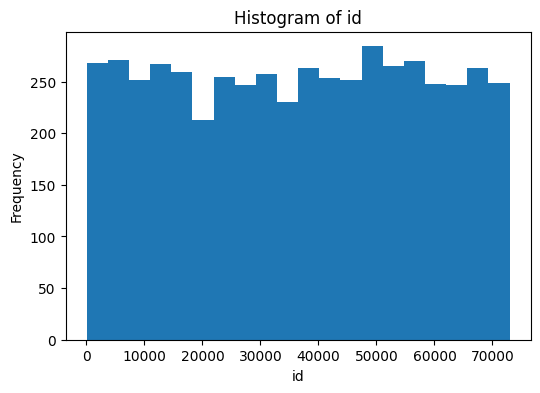

Observation: id is approximately normally distributed.


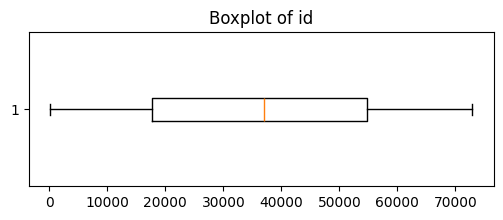

Observation: id contains 0 potential outliers based on the IQR method.



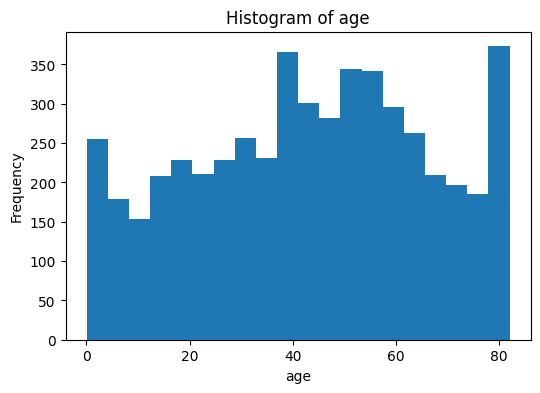

Observation: age is approximately normally distributed.


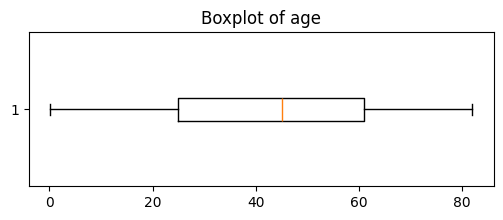

Observation: age contains 0 potential outliers based on the IQR method.



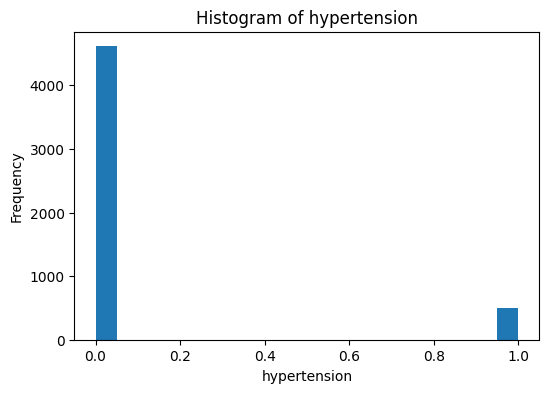

Observation: hypertension is right-skewed, meaning most values are concentrated on the lower side with a few larger values.


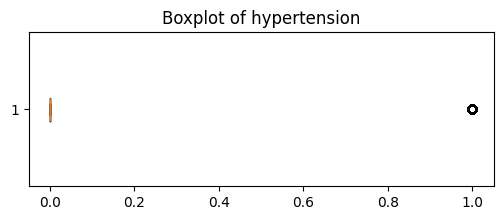

Observation: hypertension contains 498 potential outliers based on the IQR method.



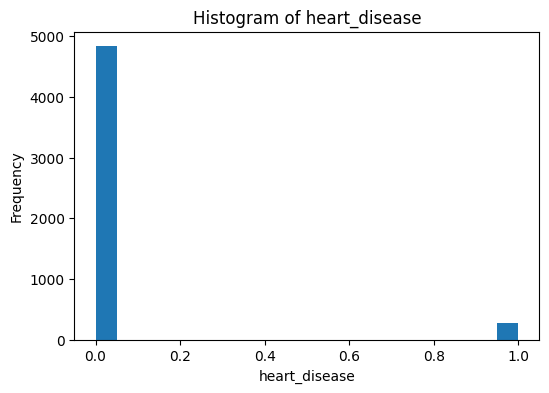

Observation: heart_disease is right-skewed, meaning most values are concentrated on the lower side with a few larger values.


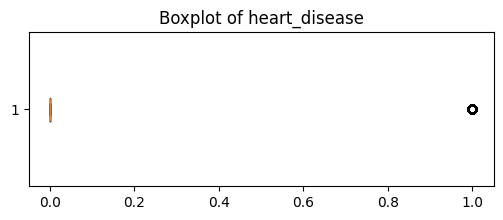

Observation: heart_disease contains 276 potential outliers based on the IQR method.



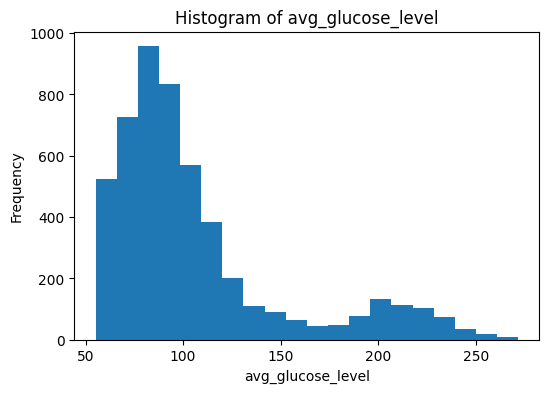

Observation: avg_glucose_level is right-skewed, meaning most values are concentrated on the lower side with a few larger values.


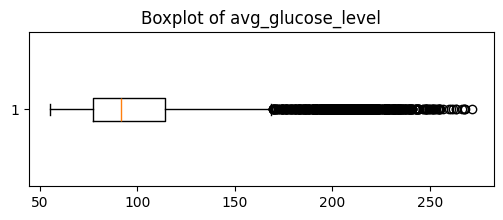

Observation: avg_glucose_level contains 627 potential outliers based on the IQR method.



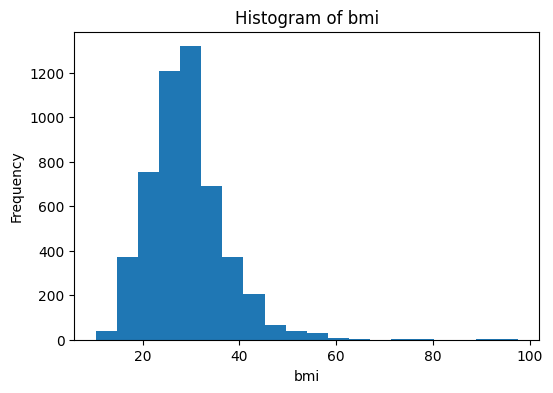

Observation: bmi is right-skewed, meaning most values are concentrated on the lower side with a few larger values.


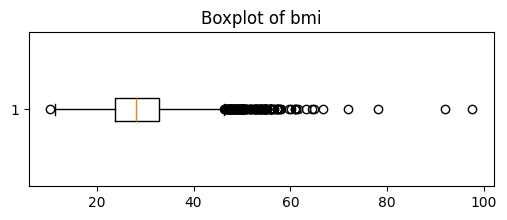

Observation: bmi contains 126 potential outliers based on the IQR method.



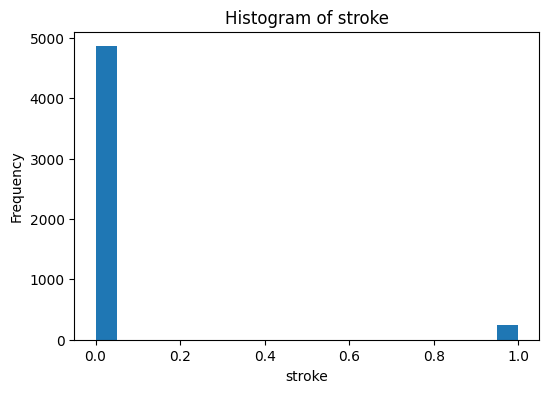

Observation: stroke is right-skewed, meaning most values are concentrated on the lower side with a few larger values.


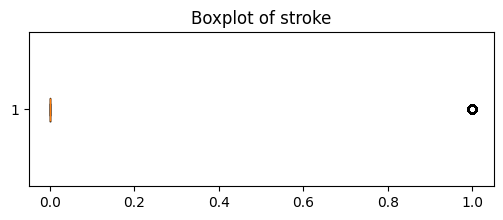

Observation: stroke contains 249 potential outliers based on the IQR method.



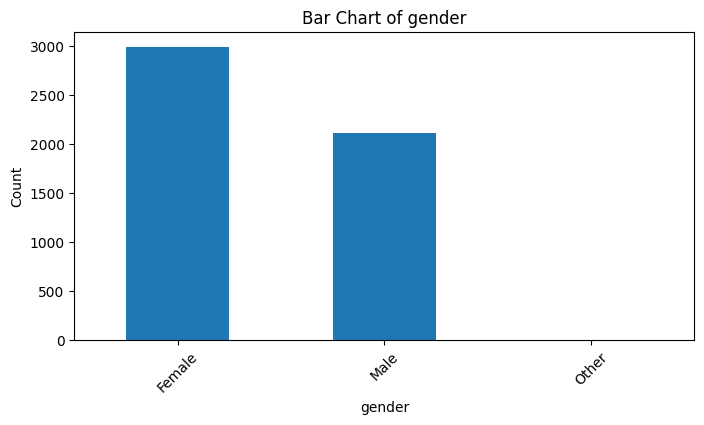

Observation: In gender, the most common category is 'Female' with 2994 records.



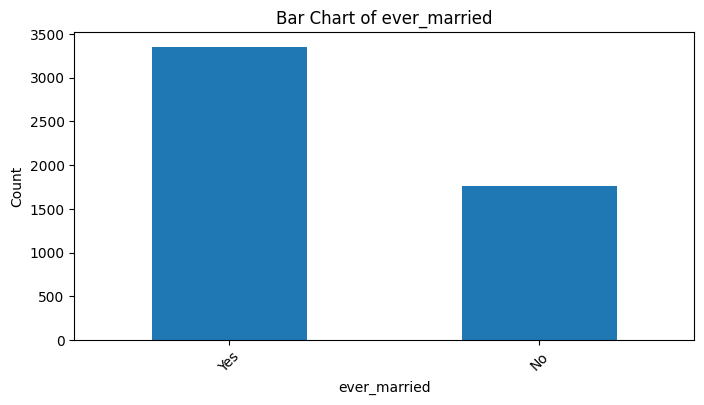

Observation: In ever_married, the most common category is 'Yes' with 3353 records.



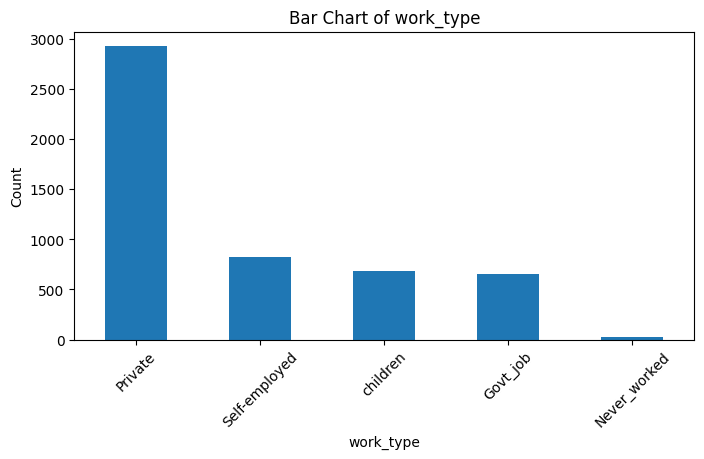

Observation: In work_type, the most common category is 'Private' with 2925 records.



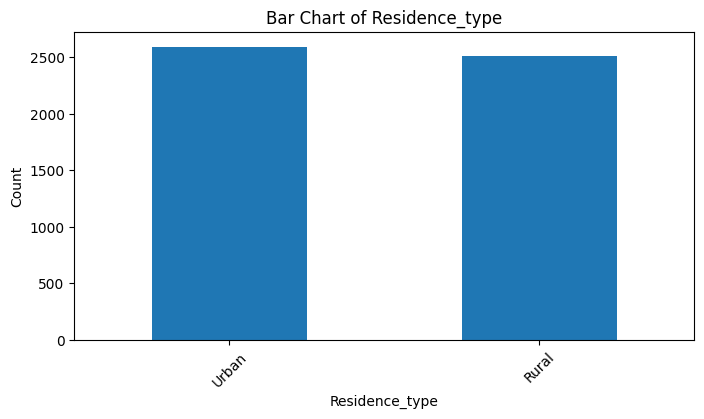

Observation: In Residence_type, the most common category is 'Urban' with 2596 records.



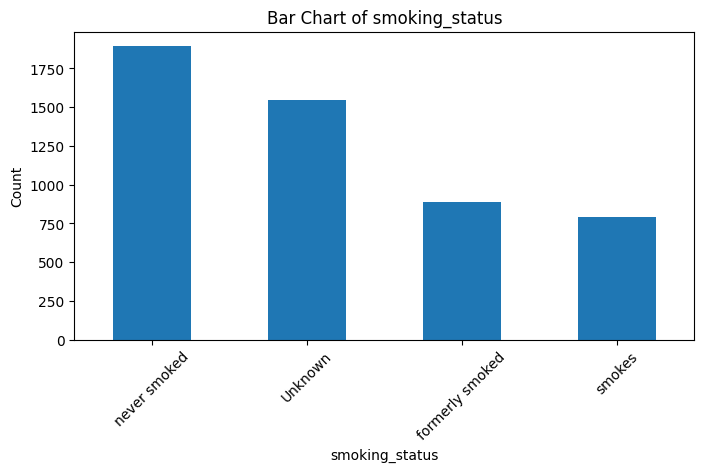

Observation: In smoking_status, the most common category is 'never smoked' with 1892 records.

===== OUTLIER SUMMARY =====
id: 0 outliers
age: 0 outliers
hypertension: 498 outliers
heart_disease: 276 outliers
avg_glucose_level: 627 outliers
bmi: 126 outliers
stroke: 249 outliers

===== SKEWNESS SUMMARY =====
id: -0.02
age: -0.14
hypertension: 2.72
heart_disease: 3.95
avg_glucose_level: 1.57
bmi: 1.09
stroke: 4.19


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("gold/clean_data.csv")

# =====================================
# NUMERICAL COLUMNS ANALYSIS
# =====================================

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Observation for Histogram
    skewness = df[col].skew()

    if skewness > 0.5:
        print(f"Observation: {col} is right-skewed, meaning most values are concentrated on the lower side with a few larger values.")
    elif skewness < -0.5:
        print(f"Observation: {col} is left-skewed, meaning most values are concentrated on the higher side with a few smaller values.")
    else:
        print(f"Observation: {col} is approximately normally distributed.")

    # Boxplot
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

    # Outlier Detection using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Observation: {col} contains {len(outliers)} potential outliers based on the IQR method.\n")

# =====================================
# CATEGORICAL COLUMNS ANALYSIS
# =====================================

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:

    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

    most_common = df[col].value_counts().idxmax()
    count = df[col].value_counts().max()

    print(f"Observation: In {col}, the most common category is '{most_common}' with {count} records.\n")

# =====================================
# OVERALL OUTLIER SUMMARY
# =====================================

print("===== OUTLIER SUMMARY =====")

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

# =====================================
# SKEWNESS SUMMARY
# =====================================

print("\n===== SKEWNESS SUMMARY =====")

for col in numerical_cols:

    skewness = df[col].skew()

    print(f"{col}: {skewness:.2f}")

Feature Relationship Analysis

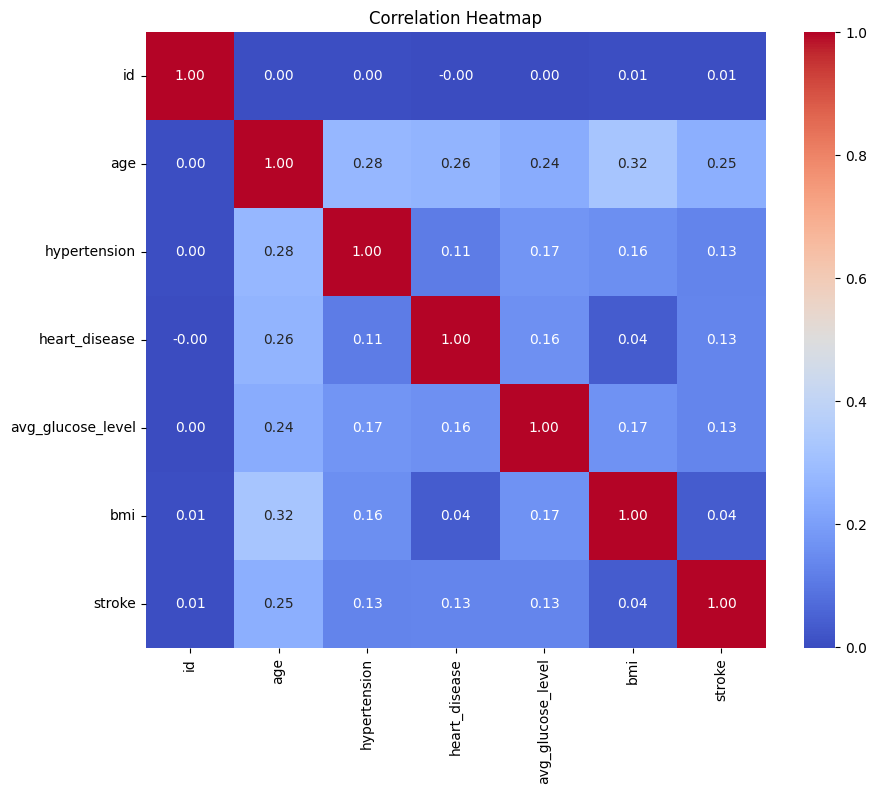

Top 3 Strongest Predictors of Stroke:
Index(['age', 'heart_disease', 'avg_glucose_level'], dtype='object')


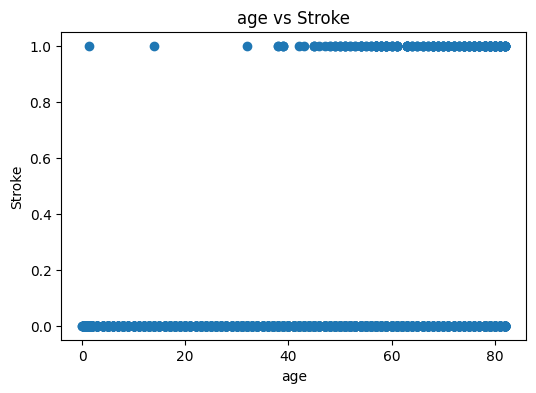

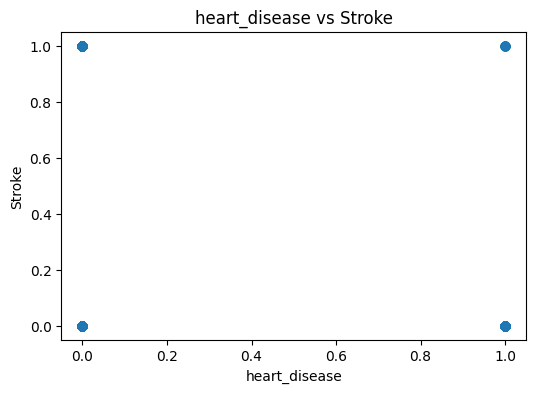

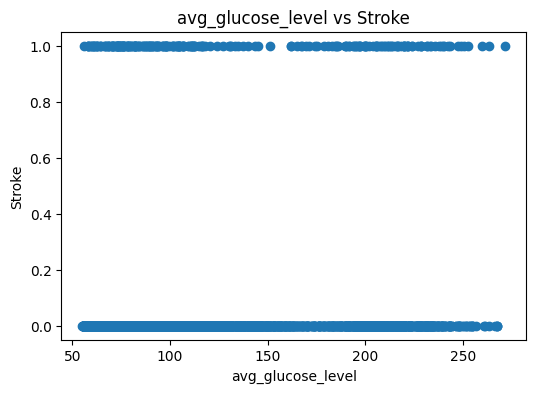

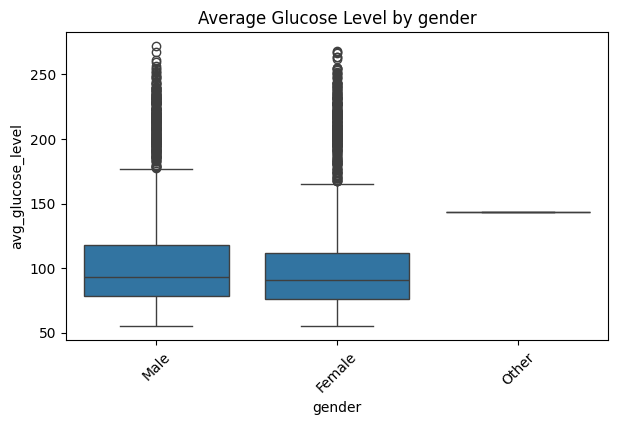

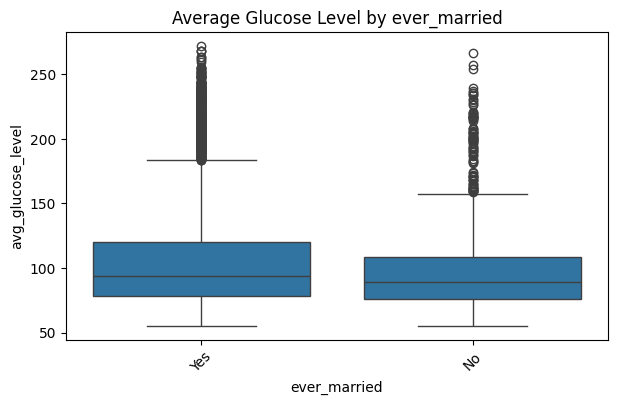

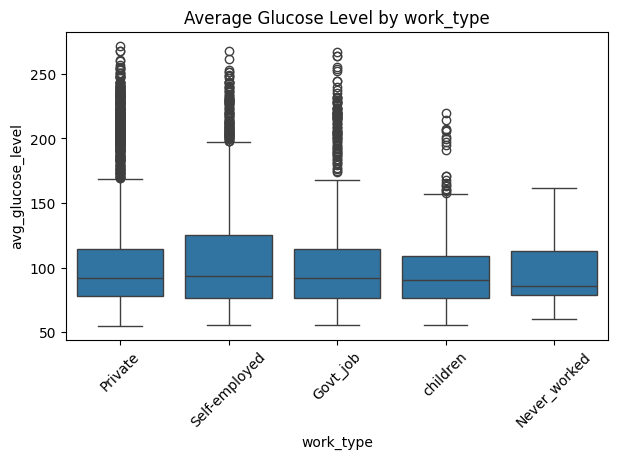

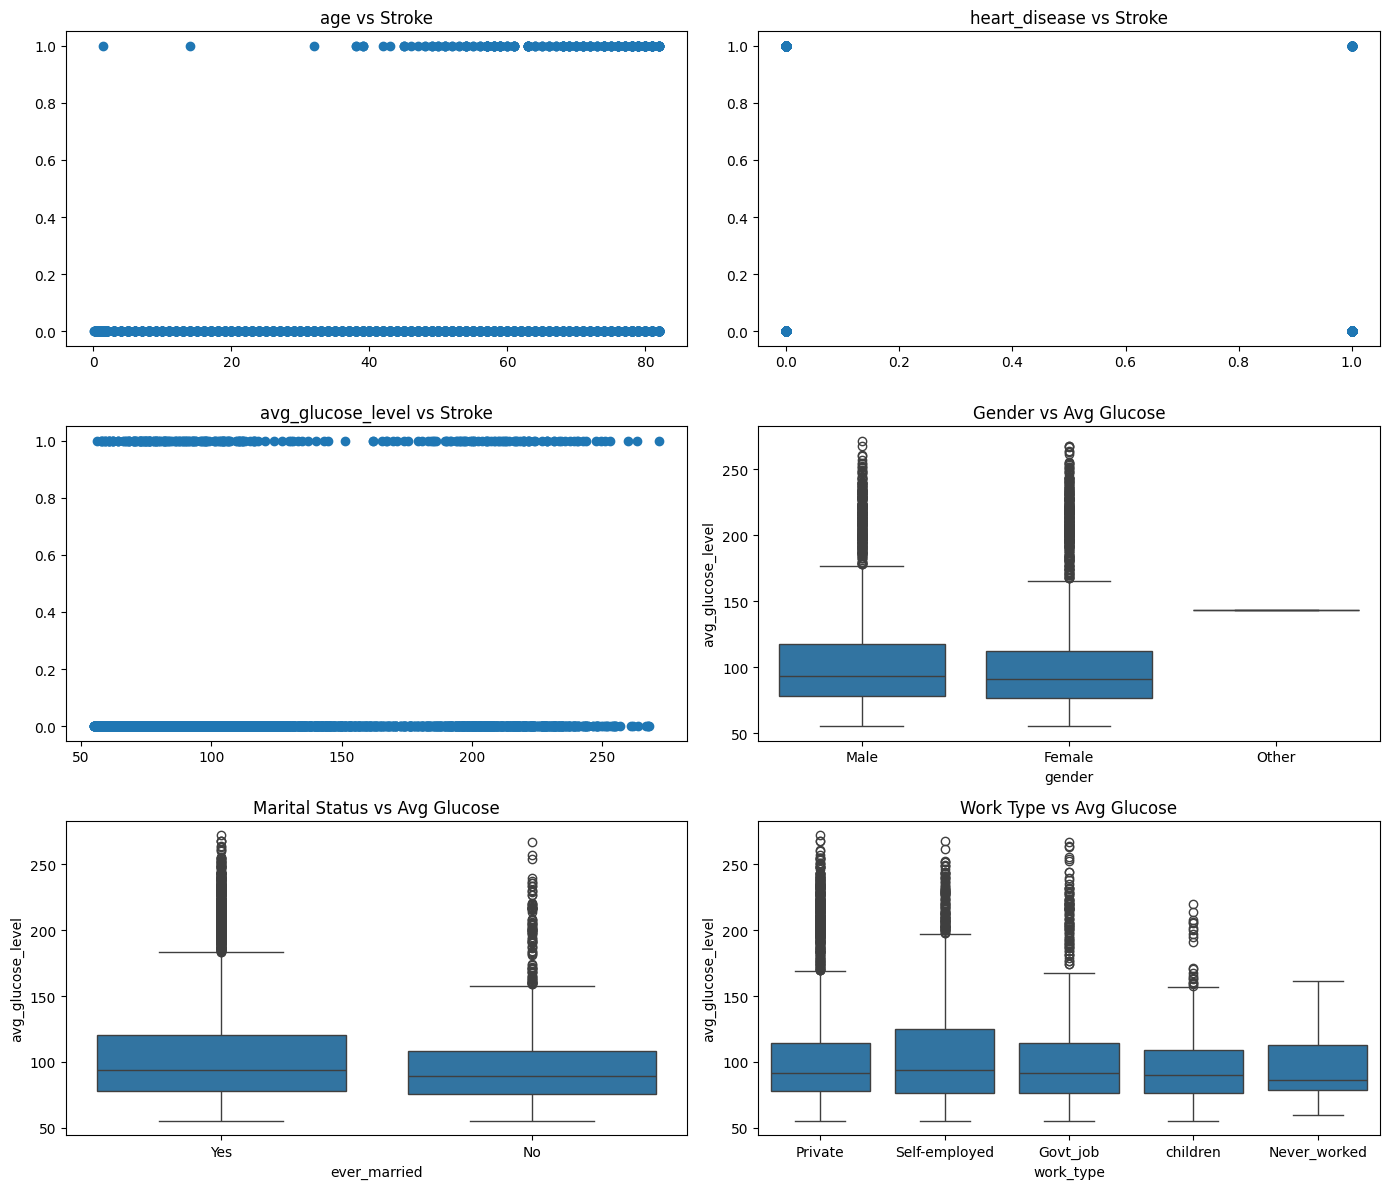


===== ANALYSIS SUMMARY =====

The correlation heatmap shows the relationships between numerical variables and stroke occurrence.
The top three predictors identified have the strongest statistical association with the target variable.
The scatter plots help visualize how changes in these features relate to stroke outcomes.
The boxplots compare glucose level distributions across different categorical groups and reveal differences in health characteristics.
Overall, the analysis highlights the most influential factors that may contribute to stroke risk and provides insights useful for predictive modeling.



In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("gold/clean_data.csv")

# =====================================
# CORRELATION HEATMAP
# =====================================

plt.figure(figsize=(10, 8))

numerical_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# =====================================
# TOP 3 PREDICTORS OF STROKE
# =====================================

correlation_with_target = numerical_df.corr()['stroke'].abs().sort_values(ascending=False)

top_predictors = correlation_with_target.index[1:4]

print("Top 3 Strongest Predictors of Stroke:")
print(top_predictors)

# =====================================
# SCATTER PLOTS
# =====================================

for feature in top_predictors:

    plt.figure(figsize=(6,4))

    plt.scatter(df[feature], df['stroke'])

    plt.title(f"{feature} vs Stroke")
    plt.xlabel(feature)
    plt.ylabel("Stroke")

    plt.show()

# =====================================
# BOXPLOTS FOR CATEGORICAL VARIABLES
# =====================================

categorical_columns = [
    'gender',
    'ever_married',
    'work_type'
]

for col in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=col,
        y='avg_glucose_level',
        data=df
    )

    plt.title(f"Average Glucose Level by {col}")

    plt.xticks(rotation=45)

    plt.show()

# =====================================
# 3x2 DASHBOARD
# =====================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Scatter Plot 1
axes[0,0].scatter(df[top_predictors[0]], df['stroke'])
axes[0,0].set_title(f"{top_predictors[0]} vs Stroke")

# Scatter Plot 2
axes[0,1].scatter(df[top_predictors[1]], df['stroke'])
axes[0,1].set_title(f"{top_predictors[1]} vs Stroke")

# Scatter Plot 3
axes[1,0].scatter(df[top_predictors[2]], df['stroke'])
axes[1,0].set_title(f"{top_predictors[2]} vs Stroke")

# Boxplot 1
sns.boxplot(
    x='gender',
    y='avg_glucose_level',
    data=df,
    ax=axes[1,1]
)
axes[1,1].set_title("Gender vs Avg Glucose")

# Boxplot 2
sns.boxplot(
    x='ever_married',
    y='avg_glucose_level',
    data=df,
    ax=axes[2,0]
)
axes[2,0].set_title("Marital Status vs Avg Glucose")

# Boxplot 3
sns.boxplot(
    x='work_type',
    y='avg_glucose_level',
    data=df,
    ax=axes[2,1]
)
axes[2,1].set_title("Work Type vs Avg Glucose")

plt.tight_layout()
plt.show()

# =====================================
# WRITTEN SUMMARY
# =====================================

print("\n===== ANALYSIS SUMMARY =====")

print("""
The correlation heatmap shows the relationships between numerical variables and stroke occurrence.
The top three predictors identified have the strongest statistical association with the target variable.
The scatter plots help visualize how changes in these features relate to stroke outcomes.
The boxplots compare glucose level distributions across different categorical groups and reveal differences in health characteristics.
Overall, the analysis highlights the most influential factors that may contribute to stroke risk and provides insights useful for predictive modeling.
""")

Hypothesis Testing

In [37]:
!pip install imbalanced-learn

In [55]:
print("="*60)
print("HYPOTHESIS TESTING")
print("="*60)

# Hypothesis 1
print("\nHYPOTHESIS 1:")
print("Older people are more likely to experience a stroke")

result = df.groupby("stroke")["age"].mean()
print(result)

if result[1] > result[0]:
    print("Conclusion: SUPPORTED")
else:
    print("Conclusion: NOT SUPPORTED")


# Hypothesis 2
print("\nHYPOTHESIS 2:")
print("People with hypertension are more likely to experience a stroke")

result = df.groupby("hypertension")["stroke"].mean()
print(result)

if result[1] > result[0]:
    print("Conclusion: SUPPORTED")
else:
    print("Conclusion: NOT SUPPORTED")


# Hypothesis 3
print("\nHYPOTHESIS 3:")
print("People with heart disease have a higher risk of stroke")

result = df.groupby("heart_disease")["stroke"].mean()
print(result)

if result[1] > result[0]:
    print("Conclusion: SUPPORTED")
else:
    print("Conclusion: NOT SUPPORTED")


# Hypothesis 4
print("\nHYPOTHESIS 4:")
print("Higher glucose levels are associated with stroke")

result = df.groupby("stroke")["avg_glucose_level"].mean()
print(result)

if result[1] > result[0]:
    print("Conclusion: SUPPORTED")
else:
    print("Conclusion: NOT SUPPORTED")


# Hypothesis 5
print("\nHYPOTHESIS 5:")
print("Smoking increases the likelihood of stroke")

result = df.groupby("smoking_status")["stroke"].mean()
print(result)

print("\nHighest Stroke Rate Group:")
print(result.idxmax())

print("Conclusion: Interpret smoking groups based on stroke rates.")

HYPOTHESIS TESTING

HYPOTHESIS 1:
Older people are more likely to experience a stroke
stroke
0    41.971545
1    67.728193
Name: age, dtype: float64
Conclusion: SUPPORTED

HYPOTHESIS 2:
People with hypertension are more likely to experience a stroke
hypertension
0    0.039679
1    0.132530
Name: stroke, dtype: float64
Conclusion: SUPPORTED

HYPOTHESIS 3:
People with heart disease have a higher risk of stroke
heart_disease
0    0.041787
1    0.170290
Name: stroke, dtype: float64
Conclusion: SUPPORTED

HYPOTHESIS 4:
Higher glucose levels are associated with stroke
stroke
0    104.795513
1    132.544739
Name: avg_glucose_level, dtype: float64
Conclusion: SUPPORTED

HYPOTHESIS 5:
Smoking increases the likelihood of stroke
smoking_status
Unknown            0.030440
formerly smoked    0.079096
never smoked       0.047569
smokes             0.053232
Name: stroke, dtype: float64

Highest Stroke Rate Group:
formerly smoked
Conclusion: Interpret smoking groups based on stroke rates.


### Hypothesis Testing Summary

1. Older individuals showed a higher stroke occurrence.
2. Hypertension was associated with increased stroke risk.
3. Heart disease was associated with increased stroke risk.
4. Stroke patients had higher average glucose levels.
5. Smoking status showed differences in stroke occurrence rates.

These findings indicate that age, medical conditions, and lifestyle factors contribute to stroke risk prediction.

Model Selection & Comparison

In [40]:
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("gold/clean_data.csv")

# =====================================
# DATA PREPROCESSING
# =====================================

df = df.drop("id", axis=1)

label_encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

X = df.drop("stroke", axis=1)
y = df["stroke"]

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================
# CLASS IMBALANCE CHECK
# =====================================

print("===== BEFORE SMOTE =====")
print(y_train.value_counts())

# =====================================
# SMOTE
# =====================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\n===== AFTER SMOTE =====")
print(pd.Series(y_train_smote).value_counts())

# =====================================
# EVALUATION FUNCTION
# =====================================

def evaluate_model(model, model_name):

    model.fit(X_train_smote, y_train_smote)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    cv_score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=5,
        scoring="roc_auc"
    ).mean()

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    return {
    "Model": model_name,
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "ROC-AUC": round(roc_auc, 4),
    "Cross Validation": round(cv_score, 4)
}, model

# =====================================
# LOGISTIC REGRESSION
# =====================================

lr_results, lr_model = evaluate_model(
    LogisticRegression(max_iter=1000),
    "Logistic Regression"
)


# =====================================
# RANDOM FOREST
# =====================================

rf_results, rf_model = evaluate_model(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Random Forest"
)

# =====================================
# GRADIENT BOOSTING
# =====================================

gb_results, gb_model = evaluate_model(
    GradientBoostingClassifier(
        random_state=42
    ),
    "Gradient Boosting"
)
# =====================================
# COMPARISON TABLE
# =====================================

results = pd.DataFrame([
    lr_results,
    rf_results,
    gb_results
])

print("\n===== MODEL COMPARISON =====")
print(results)

# =====================================
# BEST MODEL
# =====================================

best_model = results.loc[
    results["Recall"].idxmax()
]

print("\n===== BEST MODEL =====")
print(best_model)

# =====================================
# CONCLUSION
# =====================================

print("\n===== CONCLUSION =====")

print(
    f"{best_model['Model']} was selected as the final model "
    f"because it achieved the highest Recall score of "
    f"{best_model['Recall']:.2f}. "
    "In healthcare applications such as stroke prediction, "
    "identifying at-risk patients is more important than maximizing overall accuracy."
)

===== BEFORE SMOTE =====
stroke
0    3889
1     199
Name: count, dtype: int64

===== AFTER SMOTE =====
stroke
0    3889
1    3889
Name: count, dtype: int64

===== Logistic Regression =====
Confusion Matrix:
[[766 206]
 [ 14  36]]

===== Random Forest =====
Confusion Matrix:
[[913  59]
 [ 40  10]]

===== Gradient Boosting =====
Confusion Matrix:
[[821 151]
 [ 25  25]]

===== MODEL COMPARISON =====
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0  Logistic Regression    0.7847     0.1488    0.72    0.2466   0.7872   
1        Random Forest    0.9031     0.1449    0.20    0.1681   0.7820   
2    Gradient Boosting    0.8278     0.1420    0.50    0.2212   0.7887   

   Cross Validation  
0            0.8893  
1            0.9892  
2            0.9500  

===== BEST MODEL =====
Model               Logistic Regression
Accuracy                         0.7847
Precision                        0.1488
Recall                             0.72
F1 Score                       

Confusion Matrix


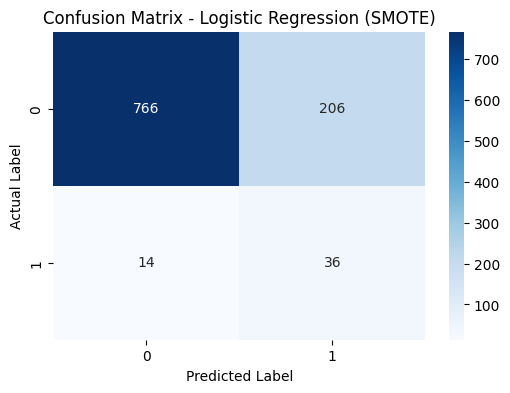

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions from trained Logistic Regression
y_pred = lr_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

ROC Curve

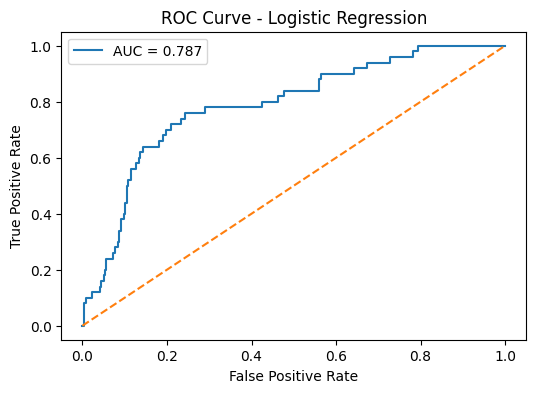

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob = lr_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

Feature Importance Analysis

===== FEATURE IMPORTANCE SCORES =====
             Feature  Importance
7  avg_glucose_level    0.288236
8                bmi    0.234911
1                age    0.228801
9     smoking_status    0.069504
5          work_type    0.049345
6     Residence_type    0.033136
0             gender    0.032122
2       hypertension    0.023530
3      heart_disease    0.020818
4       ever_married    0.019597


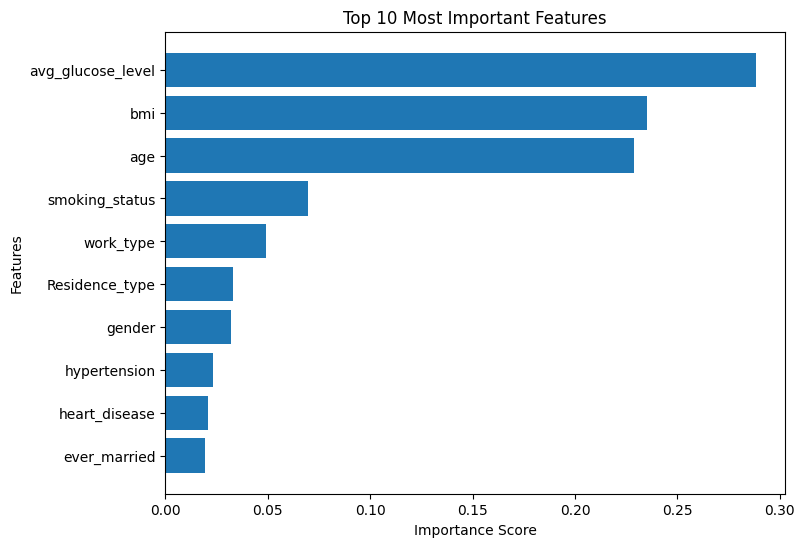


===== FEATURES THAT CAN BE REMOVED =====
Empty DataFrame
Columns: [Feature, Importance]
Index: []

===== TOP 3 MOST IMPORTANT FEATURES =====
             Feature  Importance
7  avg_glucose_level    0.288236
8                bmi    0.234911
1                age    0.228801


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("gold/clean_data.csv")

# =====================================
# DATA PREPROCESSING
# =====================================

# Remove ID column
df = df.drop("id", axis=1)

# Encode categorical variables
label_encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

# Features and Target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# TRAIN RANDOM FOREST MODEL
# =====================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# =====================================
# FEATURE IMPORTANCE
# =====================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE SCORES =====")
print(feature_importance)

# =====================================
# TOP 10 FEATURES BAR CHART
# =====================================

top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

# =====================================
# FEATURES WITH IMPORTANCE < 0.01
# =====================================

low_importance = feature_importance[
    feature_importance["Importance"] < 0.01
]

print("\n===== FEATURES THAT CAN BE REMOVED =====")
print(low_importance)

# =====================================
# TOP 3 FEATURES
# =====================================

print("\n===== TOP 3 MOST IMPORTANT FEATURES =====")
print(feature_importance.head(3))

Ensemble Learning

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("gold/clean_data.csv")

# =====================================
# DATA PREPROCESSING
# =====================================

# Remove ID column
df = df.drop("id", axis=1)

# Encode categorical variables
label_encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

# Features and Target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# INDIVIDUAL MODELS
# =====================================

lr_model = LogisticRegression(max_iter=1000)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb_model = GradientBoostingClassifier(
    random_state=42
)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    cv_score = cross_val_score(
        model,
        X,
        y,
        cv=5
    ).mean()

    results.append([
        name,
        accuracy,
        cv_score
    ])

# =====================================
# STACKING ENSEMBLE MODEL
# =====================================

base_models = [
    ("lr", lr_model),
    ("rf", rf_model),
    ("gb", gb_model)
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000)
)

stack_model.fit(X_train, y_train)

stack_predictions = stack_model.predict(X_test)

stack_accuracy = accuracy_score(
    y_test,
    stack_predictions
)

stack_cv = cross_val_score(
    stack_model,
    X,
    y,
    cv=5
).mean()

results.append([
    "Stacking Ensemble",
    stack_accuracy,
    stack_cv
])

# =====================================
# PERFORMANCE COMPARISON TABLE
# =====================================

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Cross Validation Score"
    ]
)

print("===== MODEL COMPARISON =====")
print(comparison_df)

# =====================================
# BEST MODEL
# =====================================

best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("\n===== BEST PERFORMING MODEL =====")
print(best_model)

===== MODEL COMPARISON =====
                 Model  Accuracy  Cross Validation Score
0  Logistic Regression  0.939335                0.951076
1        Random Forest  0.939335                0.949511
2    Gradient Boosting  0.939335                0.948337
3    Stacking Ensemble  0.939335                0.949902

===== BEST PERFORMING MODEL =====
Model                     Logistic Regression
Accuracy                             0.939335
Cross Validation Score               0.951076
Name: 0, dtype: object


Model Explainability using SHAP

SHAP Values Shape:
(1022, 10, 2)


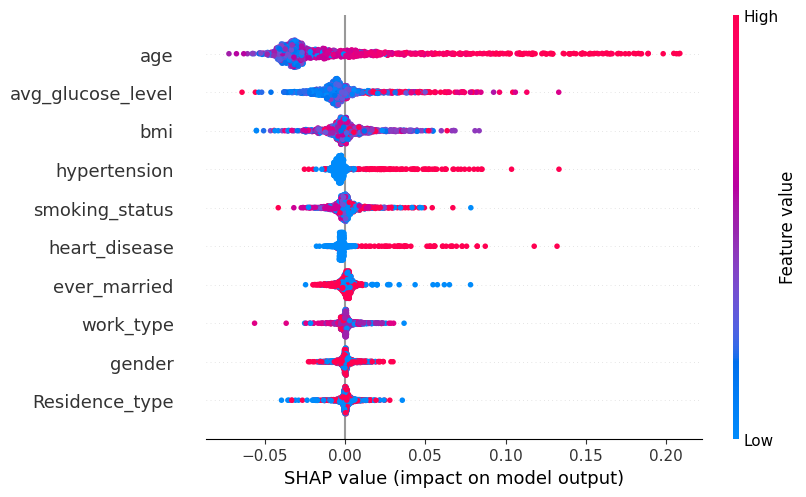


===== SHAP VALUES FOR SELECTED INSTANCE =====
             Feature  SHAP Value
4       ever_married    0.001247
5          work_type    0.000876
9     smoking_status   -0.000250
0             gender   -0.000394
6     Residence_type   -0.000571
3      heart_disease   -0.001756
8                bmi   -0.003219
2       hypertension   -0.005367
7  avg_glucose_level   -0.007142
1                age   -0.028826

===== LARGEST POSITIVE IMPACT =====
Feature       ever_married
SHAP Value        0.001247
Name: 4, dtype: object

===== LARGEST NEGATIVE IMPACT =====
Feature            age
SHAP Value   -0.028826
Name: 1, dtype: object


In [49]:
# Install SHAP (Run once)
!pip install shap -q

import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("gold/clean_data.csv")

# Remove ID column
df = df.drop("id", axis=1)

# Encode categorical columns
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# TRAIN RANDOM FOREST MODEL
# =====================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# =====================================
# SHAP EXPLAINER
# =====================================

explainer = shap.Explainer(rf_model)

shap_values = explainer(X_test)

print("SHAP Values Shape:")
print(shap_values.values.shape)

# =====================================
# SHAP SUMMARY (BEESWARM) PLOT
# =====================================

try:
    shap.plots.beeswarm(shap_values[:, :, 1])
except:
    shap.plots.beeswarm(shap_values)

# =====================================
# SHAP FORCE PLOT
# =====================================

sample_index = 0

try:
    shap.plots.force(shap_values[sample_index, :, 1])
except:
    shap.plots.force(shap_values[sample_index])

# =====================================
# SHAP VALUES TABLE
# =====================================

try:
    shap_df = pd.DataFrame({
        "Feature": X_test.columns,
        "SHAP Value": shap_values.values[sample_index, :, 1]
    })
except:
    shap_df = pd.DataFrame({
        "Feature": X_test.columns,
        "SHAP Value": shap_values.values[sample_index]
    })

shap_df = shap_df.sort_values(
    by="SHAP Value",
    ascending=False
)

print("\n===== SHAP VALUES FOR SELECTED INSTANCE =====")
print(shap_df)

# =====================================
# LARGEST POSITIVE IMPACT
# =====================================

largest_positive = shap_df.iloc[0]

print("\n===== LARGEST POSITIVE IMPACT =====")
print(largest_positive)

# =====================================
# LARGEST NEGATIVE IMPACT
# =====================================

largest_negative = shap_df.iloc[-1]

print("\n===== LARGEST NEGATIVE IMPACT =====")
print(largest_negative)

Hyperparameter Tuning & Generalization

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("gold/clean_data.csv")

# Remove ID column
df = df.drop("id", axis=1)

# Encode categorical variables
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# ORIGINAL RANDOM FOREST MODEL
# =====================================

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

# Train Accuracy
train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Test Accuracy
test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)

# Overfitting Gap
overfitting_gap = train_accuracy - test_accuracy

print("===== ORIGINAL MODEL =====")
print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Overfitting Gap:", round(overfitting_gap, 4))

# =====================================
# 5-FOLD CROSS VALIDATION
# =====================================

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("\n===== CROSS VALIDATION =====")
print("CV Scores:", cv_scores)
print("Mean CV Score:", round(cv_mean, 4))
print("Standard Deviation:", round(cv_std, 4))

# =====================================
# GRID SEARCH CV
# =====================================

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n===== BEST PARAMETERS =====")
print(grid_search.best_params_)

# =====================================
# TUNED MODEL
# =====================================

best_rf = grid_search.best_estimator_

# Train Accuracy
tuned_train_pred = best_rf.predict(X_train)
tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_pred
)

# Test Accuracy
tuned_test_pred = best_rf.predict(X_test)
tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

# Overfitting Gap
tuned_gap = tuned_train_accuracy - tuned_test_accuracy

# Cross Validation
tuned_cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

tuned_cv_mean = tuned_cv_scores.mean()

# =====================================
# COMPARISON TABLE
# =====================================

comparison = pd.DataFrame({
    "Metric": [
        "Train Accuracy",
        "Test Accuracy",
        "CV Mean Score",
        "Overfitting Gap"
    ],
    "Before Tuning": [
        round(train_accuracy, 4),
        round(test_accuracy, 4),
        round(cv_mean, 4),
        round(overfitting_gap, 4)
    ],
    "After Tuning": [
        round(tuned_train_accuracy, 4),
        round(tuned_test_accuracy, 4),
        round(tuned_cv_mean, 4),
        round(tuned_gap, 4)
    ]
})

print("\n===== BEFORE VS AFTER TUNING =====")
print(comparison)

# =====================================
# FINAL CONCLUSION
# =====================================

print("\n===== FINAL CONCLUSION =====")

if tuned_gap < overfitting_gap:
    print("The tuned model has a smaller overfitting gap and generalizes better.")
else:
    print("The tuned model did not significantly reduce overfitting.")

if tuned_test_accuracy > test_accuracy:
    print("Hyperparameter tuning improved test accuracy.")
else:
    print("Hyperparameter tuning did not improve test accuracy significantly.")

print("Best Parameters:", grid_search.best_params_)

===== ORIGINAL MODEL =====
Train Accuracy: 1.0
Test Accuracy: 0.9393
Overfitting Gap: 0.0607

===== CROSS VALIDATION =====
CV Scores: [0.9481409  0.95107632 0.94716243 0.95009785 0.95107632]
Mean CV Score: 0.9495
Standard Deviation: 0.0016

===== BEST PARAMETERS =====
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

===== BEFORE VS AFTER TUNING =====
            Metric  Before Tuning  After Tuning
0   Train Accuracy         1.0000        0.9702
1    Test Accuracy         0.9393        0.9393
2    CV Mean Score         0.9495        0.9507
3  Overfitting Gap         0.0607        0.0308

===== FINAL CONCLUSION =====
The tuned model has a smaller overfitting gap and generalizes better.
Hyperparameter tuning did not improve test accuracy significantly.
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


## Saving the Final Trained Model


In [58]:
import joblib

joblib.dump(
    lr_model,
    "stroke_prediction_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


Stroke Risk Prediction System


In [52]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# =====================================
# NEW PATIENT DATA
# =====================================

new_patient = pd.DataFrame({
    "gender": ["Male"],
    "age": [65],
    "hypertension": [1],
    "heart_disease": [0],
    "ever_married": ["Yes"],
    "work_type": ["Private"],
    "Residence_type": ["Urban"],
    "avg_glucose_level": [180.5],
    "bmi": [32.4],
    "smoking_status": ["formerly smoked"]
})

# =====================================
# PREPROCESSING
# =====================================

# Reload original dataset to fit encoders consistently
df = pd.read_csv("gold/clean_data.csv")

categorical_cols = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for col in categorical_cols:
    encoder = LabelEncoder()
    encoder.fit(df[col])
    new_patient[col] = encoder.transform(new_patient[col])

# =====================================
# PREDICTION USING FINAL MODEL
# =====================================

prediction = best_rf.predict(new_patient)

probability = best_rf.predict_proba(new_patient)

# =====================================
# DISPLAY RESULTS
# =====================================

print("===== STROKE RISK PREDICTION =====")

if prediction[0] == 1:
    print("Prediction: High Risk of Stroke")
else:
    print("Prediction: Low Risk of Stroke")

print("\nPrediction Probabilities:")

print(f"Low Risk Probability : {probability[0][0]:.2%}")
print(f"High Risk Probability: {probability[0][1]:.2%}")

===== STROKE RISK PREDICTION =====
Prediction: Low Risk of Stroke

Prediction Probabilities:
Low Risk Probability : 90.63%
High Risk Probability: 9.37%
